#  Future Frame Prediction from Video Sequences
### Deep Learning Project —dsai 308

| Field      | Details                          |
|------------|----------------------------------|
| **team member1** | Abdallah Saed      |
| **team member1**|      Ahmed Mokhter                     |
| **Dataset** |  UCF-101      |
| **Models**   |ConvLSTM2D · CNN + TCN      |

Install KaggleHub

In [ ]:
!pip install kagglehub -q

Downloading the Dataset

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("pevogam/ucf101")

DATASET_DIR = path + "/UCF101/UCF-101"

print(DATASET_DIR)

Using Colab cache for faster access to the 'ucf101' dataset.
/kaggle/input/ucf101/UCF101/UCF-101


Dataset Exploration

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("pevogam/ucf101")

DATASET_DIR = path + "/UCF101/UCF-101"

print(DATASET_DIR)

print(os.listdir(DATASET_DIR)[:20])

Using Colab cache for faster access to the 'ucf101' dataset.
/kaggle/input/ucf101/UCF101/UCF-101
['HorseRace', 'StillRings', 'ApplyLipstick', 'HammerThrow', 'VolleyballSpiking', 'Biking', 'PlayingCello', 'BodyWeightSquats', 'TaiChi', 'Punch', 'BreastStroke', 'Billiards', 'BoxingPunchingBag', 'BasketballDunk', 'PoleVault', 'ThrowDiscus', 'BaseballPitch', 'Knitting', 'SumoWrestling', 'HorseRiding']


 Imports and Configuration

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import random

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    ConvLSTM2D,
    BatchNormalization,
    Conv3D,
    Lambda
)

IMG_SIZE = 64

INPUT_FRAMES = 10

OUTPUT_FRAMES = 3

TOTAL_FRAMES = INPUT_FRAMES + OUTPUT_FRAMES

MAX_VIDEOS = 100

CLASSES = [
    "BoxingPunchingBag",
    "BoxingSpeedBag",
    "Biking",
    "JumpRope",
    "WalkingWithDog"
]

# **Video Loading and Preprocessing Function**

In [ ]:
def load_video(video_path):

    frames = []

    cap = cv2.VideoCapture(video_path)

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total < TOTAL_FRAMES:
        cap.release()
        return None

    step = max(total // TOTAL_FRAMES, 1)

    for i in range(TOTAL_FRAMES):

        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)

        success, frame = cap.read()

        if not success:
            break

        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))

        frame = frame.astype("float32") / 255.0

        frames.append(frame)

    cap.release()

    if len(frames) != TOTAL_FRAMES:
        return None

    return np.array(frames)

# **Build Input/Output Dataset Arrays**

In [ ]:
X = []

Y = []

for class_name in CLASSES:

    class_path = os.path.join(DATASET_DIR, class_name)

    videos = os.listdir(class_path)[:MAX_VIDEOS]

    for video in videos:

        video_path = os.path.join(class_path, video)

        frames = load_video(video_path)

        if frames is None:
            continue

        input_seq = frames[:INPUT_FRAMES]

        output_seq = frames[INPUT_FRAMES:]

        X.append(input_seq)

        Y.append(output_seq)

X = np.array(X)

Y = np.array(Y)

print("X Shape:", X.shape)

print("Y Shape:", Y.shape)

X Shape: (500, 10, 64, 64, 3)
Y Shape: (500, 3, 64, 64, 3)


# **Build ConvLSTM2D Model**

In [ ]:
model = Sequential()

model.add(
    ConvLSTM2D(
        filters=64,
        kernel_size=(3,3),
        input_shape=(INPUT_FRAMES, IMG_SIZE, IMG_SIZE, 3),
        padding="same",
        return_sequences=True,
        activation="relu"
    )
)

model.add(BatchNormalization())

model.add(
    ConvLSTM2D(
        filters=64,
        kernel_size=(3,3),
        padding="same",
        return_sequences=True,
        activation="relu"
    )
)

model.add(BatchNormalization())

model.add(
    Lambda(lambda x: x[:, -OUTPUT_FRAMES:, :, :, :])
)

model.add(
    Conv3D(
        filters=3,
        kernel_size=(3,3,3),
        activation="sigmoid",
        padding="same"
    )
)

model.compile(
    loss="mse",
    optimizer="adam"
)

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d_19 (ConvLSTM2D)     │ (None, 10, 64, 64, 64) │       154,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 10, 64, 64, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_20 (ConvLSTM2D)     │ (None, 10, 64, 64, 64) │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 10, 64, 64, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 3, 64, 64, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_8 (Conv3D)               │ (None, 3, 64, 64, 3)   │         5,187 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,491 (1.74 MB)

 Trainable params: 455,235 (1.74 MB)

 Non-trainable params: 256 (1.00 KB)

# **Train ConvLSTM2D Model**

In [ ]:
history = model.fit(
    X,
    Y,
    epochs=100,
    batch_size=4,
    validation_split=0.2
)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 172ms/step - loss: 0.0347 - val_loss: 0.0663
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 155ms/step - loss: 0.0280 - val_loss: 0.0614
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - loss: 0.0253 - val_loss: 0.0542
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - loss: 0.0258 - val_loss: 0.0518
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - loss: 0.0243 - val_loss: 0.0414
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step - loss: 0.0237 - val_loss: 0.0371
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - loss: 0.0243 - val_loss: 0.0372
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step - loss: 0.0238 - val_loss: 0.0398
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - loss: 0.0227 - val_loss: 0.0376
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step - loss: 0.0228 - val_loss: 0.0339
Epoch 11/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - loss: 0.0230 - val_loss: 0.0366
Epoch 12

# **Sample a Test Clip for ConvLSTM Prediction**

In [ ]:
sample = random.randint(0, len(X)-1)

input_frames = X[sample]

true_future = Y[sample]

predicted_future = model.predict(
    np.expand_dims(input_frames, axis=0)
)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


# **Visualize ConvLSTM Predictions vs Ground Truth**

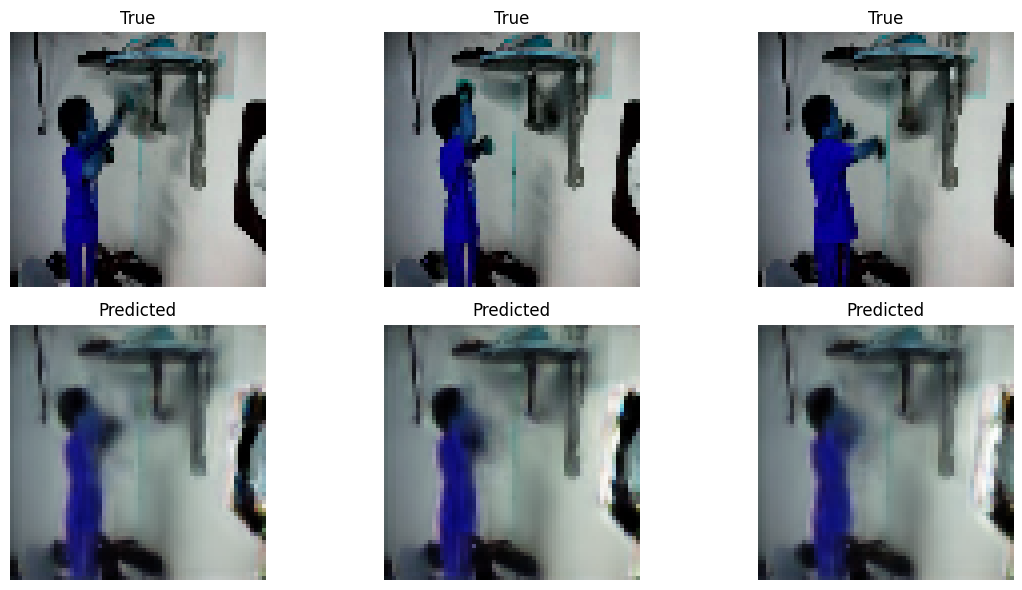

In [ ]:
plt.figure(figsize=(12,6))

for i in range(OUTPUT_FRAMES):

    plt.subplot(2, OUTPUT_FRAMES, i+1)

    plt.imshow(true_future[i])

    plt.title("True")

    plt.axis("off")

    plt.subplot(2, OUTPUT_FRAMES, OUTPUT_FRAMES+i+1)

    plt.imshow(predicted_future[i])

    plt.title("Predicted")

    plt.axis("off")

plt.tight_layout()

plt.show()

# **TCN**

Install keras-tcn


In [ ]:
!pip install keras-tcn -q

 TCN Imports

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    TimeDistributed,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Reshape
)

from tcn import TCN

# **Build TCN Model**

In [ ]:
inputs = Input(shape=(INPUT_FRAMES, IMG_SIZE, IMG_SIZE, 3))

x = TimeDistributed(
    Conv2D(
        32,
        (3,3),
        activation="relu",
        padding="same"
    )
)(inputs)

x = TimeDistributed(
    MaxPooling2D((2,2))
)(x)

x = TimeDistributed(
    Conv2D(
        64,
        (3,3),
        activation="relu",
        padding="same"
    )
)(x)

x = TimeDistributed(
    MaxPooling2D((2,2))
)(x)

x = TimeDistributed(
    Flatten()
)(x)

x = TCN(
    128,
    return_sequences=False
)(x)

x = Dense(
    OUTPUT_FRAMES * IMG_SIZE * IMG_SIZE * 3,
    activation="sigmoid"
)(x)

outputs = Reshape(
    (OUTPUT_FRAMES, IMG_SIZE, IMG_SIZE, 3)
)(x)

tcn_model = Model(inputs, outputs)

tcn_model.compile(
    optimizer="adam",
    loss="mse"
)

tcn_model.summary()

Model: "functional_55"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 10, 64, 64, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 64, 64, 32) │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 32, 32, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 32, 32, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 16, 16, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 10, 16384)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn (TCN)                       │ (None, 128)            │     8,930,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 36864)          │     4,755,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 64, 64, 3)   │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,705,792 (52.28 MB)

 Trainable params: 13,705,792 (52.28 MB)

 Non-trainable params: 0 (0.00 B)

# **Train TCN Model**

In [ ]:
tcn_history = tcn_model.fit(
    X,
    Y,
    epochs=100,
    batch_size=4,
    validation_split=0.2
)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0107 - val_loss: 0.0515
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0106 - val_loss: 0.0512
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0105 - val_loss: 0.0508
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0105 - val_loss: 0.0519
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0103 - val_loss: 0.0513
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0103 - val_loss: 0.0516
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0101 - val_loss: 0.0517
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0100 - val_loss: 0.0505
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0099 - val_loss: 0.0513
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0098 - val_loss: 0.0513
Epoch 11/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0098 - val_loss: 0.0510
Epoch 12/100
100/100 ━━━━━━━━━

# **Sample a Test Clip for TCN Prediction**

In [ ]:
sample = random.randint(0, len(X)-1)

input_frames = X[sample]

true_future = Y[sample]

predicted_future = tcn_model.predict(
    np.expand_dims(input_frames, axis=0)
)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


# Visualize TCN Predictions vs Ground Truth

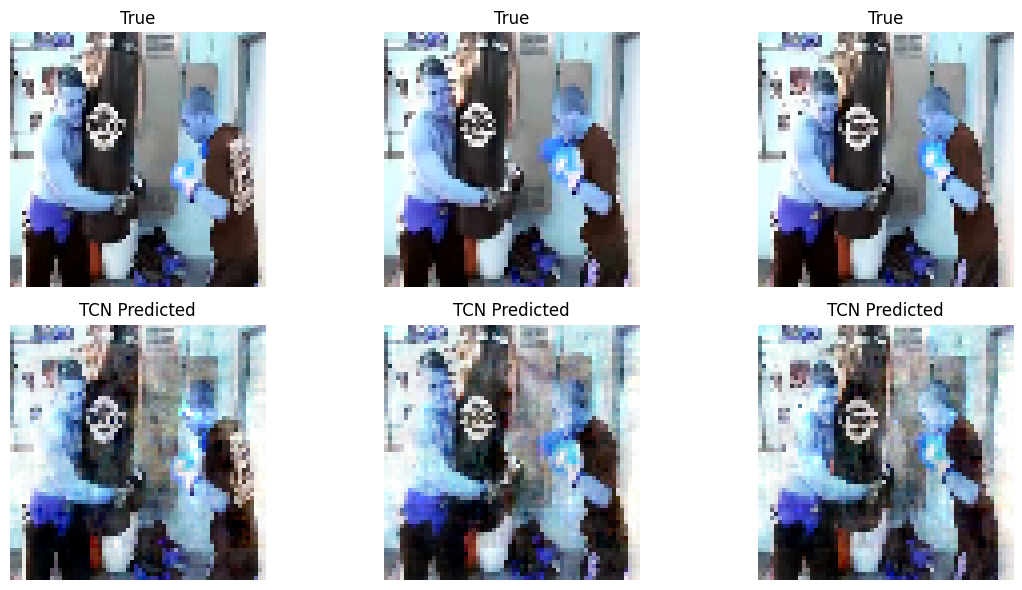

In [ ]:
plt.figure(figsize=(12,6))

for i in range(OUTPUT_FRAMES):

    plt.subplot(2, OUTPUT_FRAMES, i+1)

    plt.imshow(true_future[i])

    plt.title("True")

    plt.axis("off")

    plt.subplot(2, OUTPUT_FRAMES, OUTPUT_FRAMES+i+1)

    plt.imshow(predicted_future[i])

    plt.title("TCN Predicted")

    plt.axis("off")

plt.tight_layout()

plt.show()

# ** MSE Comparison**

In [ ]:
from sklearn.metrics import mean_squared_error

convlstm_pred = model.predict(
    np.expand_dims(input_frames, axis=0)
)[0]

tcn_pred = tcn_model.predict(
    np.expand_dims(input_frames, axis=0)
)[0]

true_flat = true_future.flatten()

convlstm_flat = convlstm_pred.flatten()

tcn_flat = tcn_pred.flatten()

convlstm_mse = mean_squared_error(
    true_flat,
    convlstm_flat
)

tcn_mse = mean_squared_error(
    true_flat,
    tcn_flat
)

print("ConvLSTM MSE:", convlstm_mse)

print("TCN MSE:", tcn_mse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
ConvLSTM MSE: 0.032396119087934494
TCN MSE: 0.0060094138607382774


# **Side-by-Side Visual Comparison (Both Models)**

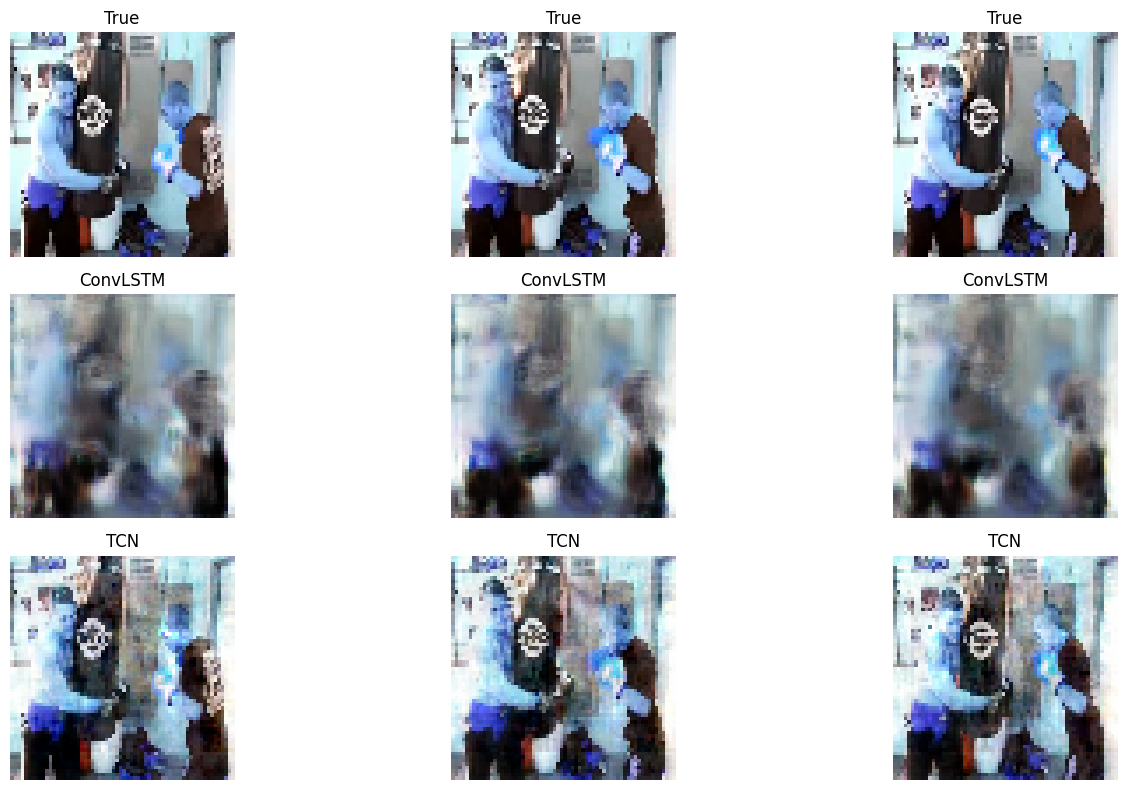

In [ ]:
plt.figure(figsize=(15,8))

for i in range(OUTPUT_FRAMES):

    plt.subplot(3, OUTPUT_FRAMES, i+1)

    plt.imshow(true_future[i])

    plt.title("True")

    plt.axis("off")

    plt.subplot(3, OUTPUT_FRAMES, OUTPUT_FRAMES+i+1)

    plt.imshow(convlstm_pred[i])

    plt.title("ConvLSTM")

    plt.axis("off")

    plt.subplot(3, OUTPUT_FRAMES, (2*OUTPUT_FRAMES)+i+1)

    plt.imshow(tcn_pred[i])

    plt.title("TCN")

    plt.axis("off")

plt.tight_layout()

plt.show()

 Plot Training and Validation Loss Curves

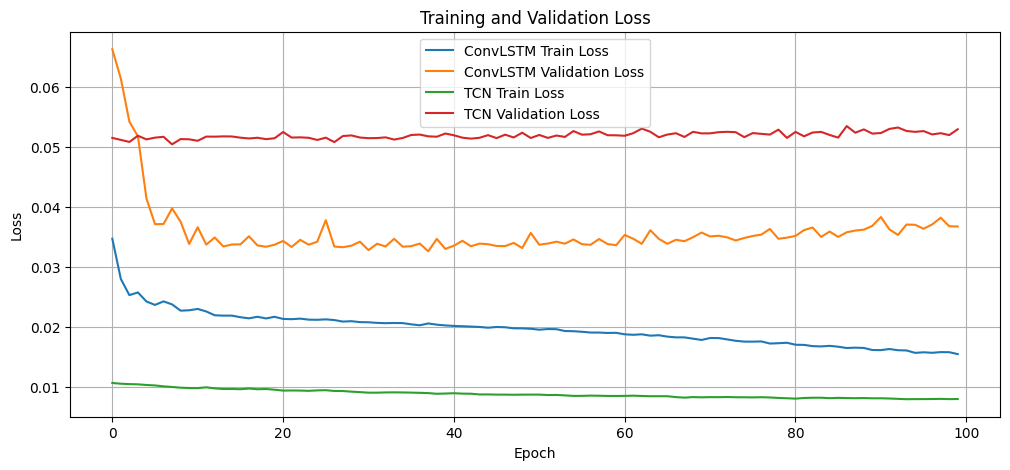

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    history.history['loss'],
    label='ConvLSTM Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='ConvLSTM Validation Loss'
)

plt.plot(
    tcn_history.history['loss'],
    label='TCN Train Loss'
)

plt.plot(
    tcn_history.history['val_loss'],
    label='TCN Validation Loss'
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

 MSE and RMSE

In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt

convlstm_predictions = model.predict(X)

tcn_predictions = tcn_model.predict(X)

convlstm_mse = mean_squared_error(
    Y.flatten(),
    convlstm_predictions.flatten()
)

tcn_mse = mean_squared_error(
    Y.flatten(),
    tcn_predictions.flatten()
)

convlstm_rmse = sqrt(convlstm_mse)

tcn_rmse = sqrt(tcn_mse)

print("ConvLSTM MSE:", convlstm_mse)

print("TCN MSE:", tcn_mse)

print()

print("ConvLSTM RMSE:", convlstm_rmse)

print("TCN RMSE:", tcn_rmse)

16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 366ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 161ms/step
ConvLSTM MSE: 0.019650883972644806
TCN MSE: 0.016601618379354477

ConvLSTM RMSE: 0.14018161067930704
TCN RMSE: 0.12884726764411605


# **Compute Average PSNR per Model**

In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr

convlstm_psnr_scores = []

tcn_psnr_scores = []

for i in range(len(Y)):

    true_frame = Y[i][0]

    conv_frame = convlstm_predictions[i][0]

    tcn_frame = tcn_predictions[i][0]

    conv_score = psnr(
        true_frame,
        conv_frame,
        data_range=1.0
    )

    tcn_score = psnr(
        true_frame,
        tcn_frame,
        data_range=1.0
    )

    convlstm_psnr_scores.append(conv_score)

    tcn_psnr_scores.append(tcn_score)

avg_convlstm_psnr = np.mean(convlstm_psnr_scores)

avg_tcn_psnr = np.mean(tcn_psnr_scores)

print("ConvLSTM Average PSNR:", avg_convlstm_psnr)

print("TCN Average PSNR:", avg_tcn_psnr)

ConvLSTM Average PSNR: 18.445316281276362
TCN Average PSNR: 19.889229802740193


# **Final Comparison Table**

In [ ]:
import pandas as pd

comparison_table = pd.DataFrame({

    "Model": [
        "ConvLSTM",
        "TCN"
    ],

    "MSE": [
        convlstm_mse,
        tcn_mse
    ],

    "RMSE": [
        convlstm_rmse,
        tcn_rmse
    ],

    "PSNR": [
        avg_convlstm_psnr,
        avg_tcn_psnr
    ]
})

comparison_table

,Model,MSE,RMSE,PSNR
0,ConvLSTM,0.019651,0.140182,18.445316
1,TCN,0.016602,0.128847,19.889230
